# Learning by Pruning — Weight-Level Sensitivity Analysis

Same sweeps as `sensitivity_analysis_alternatives.ipynb`, but pruning individual W2 weights instead of hidden units. Each utility function from the unit-level notebook translates naturally to weight-level: the unit-level utility was the sum of its outgoing-weight utilities, so dropping the sum gives a per-weight utility. LTU activation only.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from torchvision import datasets
from itertools import product
from tqdm.auto import tqdm

from phd.research_utils.analysis.plotting import plot_param_sensitivity
from phd.jax_core.models import ltu

SEED = 262403
SCAN_UNROLL = 10
INPUT_SIZE = 784
OUTPUT_SIZE = 10

ACTIVATIONS = {
    'relu': jax.nn.relu,
    'ltu': ltu,
    'sigmoid': jax.nn.sigmoid,
}

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Load MNIST once ───────────────────────────────────────────────────
train_dataset = datasets.MNIST(root="./data", train=True, download=True)

all_images_np = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32)
all_images_np = all_images_np / 255.0
all_labels_np = train_dataset.targets.numpy()
print(f"Loaded {len(all_labels_np)} training images")

Loaded 60000 training images


In [3]:
# ── Experiment function ───────────────────────────────────────────────

def forward(x, W1, W2, mask, act_fn):
    # mask is (hidden, out): individual W2 weights are gated
    h = act_fn(x @ W1)
    logits = h @ (W2 * mask)
    return logits, h


# V0
# Per-weight version of the baseline utility: drop the sum over outputs.
# Unit-level baseline summed |error+c| - |error| across outputs to get per-unit utility;
# here each (i, j) entry is the contribution of weight W2[i, j] directly.
def compute_weight_utility(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]            # (in, out)
    U = jnp.abs(error + c) - jnp.abs(error) # (in, out)
    return U

# V0.5
# Per-output raw-sum scaling — the summing step at the end of the unit-level version
# is removed; the per-output scale itself still applies to each (i, j).
def compute_scaled_weight_utility(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]
    U_raw = jnp.abs(error + c) - jnp.abs(error)  # (in, out)

    error_reduced = jnp.abs(targets) - jnp.abs(error)            # (out,)
    U_raw_sum = jnp.sum(U_raw, axis=0)                           # (out,)
    scale = jnp.where(jnp.abs(U_raw_sum) > 1e-10, error_reduced / U_raw_sum, 1.0)
    return U_raw * scale                                         # (in, out)


# Alternate utility functions (translated from the unit-level notebook):
# 1. Subtract minimum value from raw utility per output, no scaling
# 2. Subtract minimum value, then scale
# 3. Clamp negative raw utilities to zero, no scaling
# 4. Clamp negative raw utilities to zero, then scale
# 5. Scale by sum of absolute utilities (per output)
# 6. Scale by sum of positive utilities (per output)
# 7. Single global scaling factor


# 1. Subtract per-output minimum from U_raw (no scaling)
def compute_weight_utility_v1(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]
    U_raw = jnp.abs(error + c) - jnp.abs(error)
    U_shifted = U_raw - jnp.min(U_raw, axis=0, keepdims=True)
    return U_shifted


# 2. Subtract per-output minimum, then scale per output
def compute_weight_utility_v2(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]
    U_raw = jnp.abs(error + c) - jnp.abs(error)
    U_shifted = U_raw - jnp.min(U_raw, axis=0, keepdims=True)

    error_reduced = jnp.abs(targets) - jnp.abs(error)
    U_shifted_sum = jnp.sum(U_shifted, axis=0)
    scale = jnp.where(jnp.abs(U_shifted_sum) > 1e-10, error_reduced / U_shifted_sum, 1.0)
    return U_shifted * scale


# 3. Clamp negative raw utilities to zero (no scaling)
def compute_weight_utility_v3(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]
    U_raw = jnp.abs(error + c) - jnp.abs(error)
    return jnp.maximum(U_raw, 0.0)


# 4. Clamp negative raw utilities to zero, then scale per output
def compute_weight_utility_v4(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]
    U_raw = jnp.abs(error + c) - jnp.abs(error)
    U_clamped = jnp.maximum(U_raw, 0.0)

    error_reduced = jnp.abs(targets) - jnp.abs(error)
    U_clamped_sum = jnp.sum(U_clamped, axis=0)
    scale = jnp.where(jnp.abs(U_clamped_sum) > 1e-10, error_reduced / U_clamped_sum, 1.0)
    return U_clamped * scale


# 5. Scale per output by sum of absolute utilities
def compute_weight_utility_v5(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]
    U_raw = jnp.abs(error + c) - jnp.abs(error)

    error_reduced = jnp.abs(targets) - jnp.abs(error)
    U_abs_sum = jnp.sum(jnp.abs(U_raw), axis=0)
    scale = jnp.where(jnp.abs(U_abs_sum) > 1e-10, error_reduced / U_abs_sum, 1.0)
    return U_raw * scale


# 6. Scale per output by sum of positive utilities only
def compute_weight_utility_v6(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]
    U_raw = jnp.abs(error + c) - jnp.abs(error)

    error_reduced = jnp.abs(targets) - jnp.abs(error)
    U_pos_sum = jnp.sum(jnp.maximum(U_raw, 0.0), axis=0)
    scale = jnp.where(jnp.abs(U_pos_sum) > 1e-10, error_reduced / U_pos_sum, 1.0)
    return U_raw * scale


# 7. Single global scaling factor (cross-output comparable)
def compute_weight_utility_v7(h, W2, mask, error, targets):
    c = (W2 * mask) * h[:, None]
    U_raw = jnp.abs(error + c) - jnp.abs(error)  # (in, out)

    total_error_reduced = jnp.sum(jnp.abs(targets) - jnp.abs(error))  # scalar
    total_abs_utility = jnp.sum(jnp.abs(U_raw))                       # scalar
    scale = jnp.where(total_abs_utility > 1e-10, total_error_reduced / total_abs_utility, 1.0)
    return U_raw * scale



# 8. Closed-form per-weight softmax-CE leave-one-out utility.
# For weight (j, k): removing it changes logit_k by d = -h_j * W2[j, k]; the softmax-CE
# for the true class shifts by  -d * y_match[k] + log((1 - p[k]) + p[k] * e^d).
# Numerically stable form: log((1-p) + p*e^d) = logaddexp(log(1-p), d + log(p)),
# with log(1 - p_k) recovered as logsumexp over the other classes' log-probs (avoids
# log1p(-1.0) = -inf when p saturates).
def compute_weight_utility_softmax_ce(h, W2, mask, error, targets):
    logits = targets - error  # one_hot - error = logits
    log_p = jax.nn.log_softmax(logits)                            # (out,)
    # log(1 - p_k) = logsumexp over j != k of log_p_j
    diag = jnp.eye(OUTPUT_SIZE, dtype=jnp.bool_)
    log_p_off = jnp.where(diag, -jnp.inf, log_p[None, :])         # (out, out)
    log_1mp = jax.scipy.special.logsumexp(log_p_off, axis=-1)     # (out,)
    d = -h[:, None] * W2                                          # (in, out)
    a = log_1mp[None, :]
    b = d + log_p[None, :]
    return (-d * targets[None, :] + jnp.logaddexp(a, b)) * mask


UTIL_FN = compute_weight_utility


def _make_scan_step(trace_decay, act_fn):
    """Create a scan step function closed over trace_decay and activation."""
    def _scan_step(carry, data):
        W1, W2, mask, utility_trace = carry
        x, label = data

        logits, h = forward(x, W1, W2, mask, act_fn)
        correct = (jnp.argmax(logits) == label).astype(jnp.float32)

        one_hot = jax.nn.one_hot(label, OUTPUT_SIZE)
        error = one_hot - logits

        U = UTIL_FN(h, W2, mask, error, one_hot)
        utility_trace = utility_trace * trace_decay + U * (1 - trace_decay)

        carry = (W1, W2, mask, utility_trace)
        return carry, correct
    return _scan_step


# Cache of jitted scan functions keyed by (trace_decay, activation_name)
_scan_cache = {}

def _get_scan_fn(trace_decay, activation='relu'):
    cache_key = (trace_decay, activation)
    if cache_key not in _scan_cache:
        act_fn = ACTIVATIONS[activation]
        step_fn = _make_scan_step(trace_decay, act_fn)
        _scan_cache[cache_key] = jax.jit(
            lambda carry, data: jax.lax.scan(step_fn, carry, data, unroll=SCAN_UNROLL)
        )
    return _scan_cache[cache_key]


def run_pruning_experiment(
    hidden_size,
    prune_every,
    reset_traces_on_prune,
    weights_per_prune=10,
    activation='relu',
    seed=SEED,
    pbar=None,
):
    """Run a single weight-level learning-by-pruning experiment. Returns dict of results."""
    trace_decay = 1.0 - (1.0 / prune_every)
    # Prune `weights_per_prune` weights per event, down to ~1 active weight.
    total_weights = hidden_size * OUTPUT_SIZE
    n_prune_events = (total_weights + weights_per_prune - 1) // weights_per_prune

    scan_fn = _get_scan_fn(trace_decay, activation)

    # LeCun uniform initializer, no biases
    key = jax.random.PRNGKey(seed)
    k1, k2 = jax.random.split(key)
    lim1 = np.sqrt(3.0 / INPUT_SIZE)
    lim2 = np.sqrt(3.0 / hidden_size)
    W1 = jax.random.uniform(k1, (INPUT_SIZE, hidden_size), minval=-lim1, maxval=lim1)
    W2 = jax.random.uniform(k2, (hidden_size, OUTPUT_SIZE), minval=-lim2, maxval=lim2)
    mask = jnp.ones((hidden_size, OUTPUT_SIZE))
    utility_trace = jnp.zeros((hidden_size, OUTPUT_SIZE))

    # Data iteration
    rng = np.random.RandomState(seed)
    epoch_order = rng.permutation(len(all_labels_np))
    epoch_pos = 0

    def get_chunk(size):
        nonlocal epoch_order, epoch_pos
        indices = []
        remaining = size
        while remaining > 0:
            avail = len(epoch_order) - epoch_pos
            take = min(avail, remaining)
            indices.append(epoch_order[epoch_pos:epoch_pos + take])
            epoch_pos += take
            remaining -= take
            if epoch_pos >= len(epoch_order):
                epoch_order = rng.permutation(len(all_labels_np))
                epoch_pos = 0
        return np.concatenate(indices)

    all_corrects = []
    n_active_history = []
    carry = (W1, W2, mask, utility_trace)

    for prune_idx in range(n_prune_events):
        indices = get_chunk(prune_every)
        data = (jnp.array(all_images_np[indices]), jnp.array(all_labels_np[indices]))

        carry, corrects = scan_fn(carry, data)
        all_corrects.append(np.array(corrects))

        W1, W2, mask, utility_trace = carry
        n_active = int(mask.sum())
        n_active_history.append(n_active)

        # Prune the K worst-utility active weights, capped to leave at least 1 active.
        n_to_prune = min(weights_per_prune, n_active - 1)
        if n_to_prune > 0:
            score = jnp.where(mask > 0.5, utility_trace, jnp.inf)
            flat_score = score.reshape(-1)
            # top_k of -score gives the indices of the K smallest scores.
            _, bottom_idx = jax.lax.top_k(-flat_score, n_to_prune)
            rows = bottom_idx // OUTPUT_SIZE
            cols = bottom_idx % OUTPUT_SIZE
            mask = mask.at[rows, cols].set(0.0)
            if reset_traces_on_prune:
                utility_trace = jnp.zeros((hidden_size, OUTPUT_SIZE))

        carry = (W1, W2, mask, utility_trace)

        if pbar is not None:
            pbar.update(prune_every)

    # Compute per-interval accuracy
    acc_per_interval = np.array([c.mean() for c in all_corrects])

    return {
        'acc_per_interval': acc_per_interval,
        'n_active_history': np.array(n_active_history),
        'peak_accuracy': float(acc_per_interval.max()) * 100,
        'mean_accuracy': float(acc_per_interval.mean()) * 100,
        'final_accuracy': float(acc_per_interval[-1]) * 100,
    }

In [4]:
EVAL_CHUNK = 1000  # steps per evaluation chunk; best chunk = reported metric

def best_chunk_accuracy(acc_per_interval, prune_every):
    """Average accuracy over the best EVAL_CHUNK-step window."""
    all_correct = np.concatenate([np.full(int(prune_every), a) for a in acc_per_interval])
    n_steps = len(all_correct)
    n_chunks = n_steps // EVAL_CHUNK
    if n_chunks == 0:
        return float(all_correct.mean()) * 100
    trimmed = all_correct[:n_chunks * EVAL_CHUNK].reshape(n_chunks, EVAL_CHUNK)
    chunk_accs = trimmed.mean(axis=1)
    return float(chunk_accs.max()) * 100


def run_sweep(configs):
    """
    Run experiments for a list of config dicts.
    Each config must have: hidden_size, prune_every, reset_traces_on_prune.
    Optional: activation (default 'relu'), seed (default SEED).

    Returns (run_df, config_df) suitable for plot_param_sensitivity.
    run_df has one row per run with the best-EVAL_CHUNK accuracy as the metric.
    """
    run_rows = []
    config_rows = []

    # Total steps per config = n_prune_events * prune_every,
    # where n_prune_events = ceil(hidden_size * OUTPUT_SIZE / weights_per_prune).
    def _config_steps(cfg):
        K = cfg.get('weights_per_prune', 10)
        n_events = (cfg['hidden_size'] * OUTPUT_SIZE + K - 1) // K
        return n_events * cfg['prune_every']
    total_steps = sum(_config_steps(cfg) for cfg in configs)
    pbar = tqdm(total=total_steps, desc='Sweep', unit='step')

    for run_id, cfg in enumerate(configs):
        hidden_size = cfg['hidden_size']
        prune_every = cfg['prune_every']
        reset = cfg['reset_traces_on_prune']
        weights_per_prune = cfg.get('weights_per_prune', 10)
        activation = cfg.get('activation', 'relu')
        seed = cfg.get('seed', SEED)

        pbar.set_postfix(h=hidden_size, p=prune_every, reset=reset, k=weights_per_prune, act=activation)

        result = run_pruning_experiment(
            hidden_size=hidden_size,
            prune_every=prune_every,
            reset_traces_on_prune=reset,
            weights_per_prune=weights_per_prune,
            activation=activation,
            seed=seed,
            pbar=pbar,
        )

        best_acc = best_chunk_accuracy(result['acc_per_interval'], prune_every)

        run_rows.append({
            'run_id': run_id,
            'step': 0,
            'best_chunk_accuracy': best_acc,
        })

        config_rows.append({
            'run_id': run_id,
            'hidden_size': hidden_size,
            'prune_every': prune_every,
            'reset_traces_on_prune': reset,
            'weights_per_prune': weights_per_prune,
            'activation': activation,
            'seed': seed,
        })

    pbar.close()

    run_df = pd.DataFrame(run_rows)
    config_df = pd.DataFrame(config_rows)
    return run_df, config_df

## Experiment 1: Hidden Size Sensitivity (LTU)

How does the size of the hidden layer affect peak performance under weight-level pruning? Each run starts with `hidden_size × OUTPUT_SIZE` active W2 weights and prunes one weight per event until only one remains. Larger networks have proportionally more weights to prune through, so total wall clock per run scales as `hidden_size × OUTPUT_SIZE × prune_every`.

In [5]:
hidden_sizes = [25, 50, 100, 200, 400] # [100, 200, 400, 800, 1600, 3200]
reset_values = [False, True]

configs_exp1_ltu = [
    {'hidden_size': h, 'prune_every': 100, 'reset_traces_on_prune': r, 'activation': 'ltu'}
    for h, r in product(hidden_sizes, reset_values)
]

run_df_1_ltu, config_df_1_ltu = run_sweep(configs_exp1_ltu)

Sweep: 100%|██████████| 155000/155000 [00:23<00:00, 6662.16step/s, act=ltu, h=400, k=10, p=100, reset=1] 


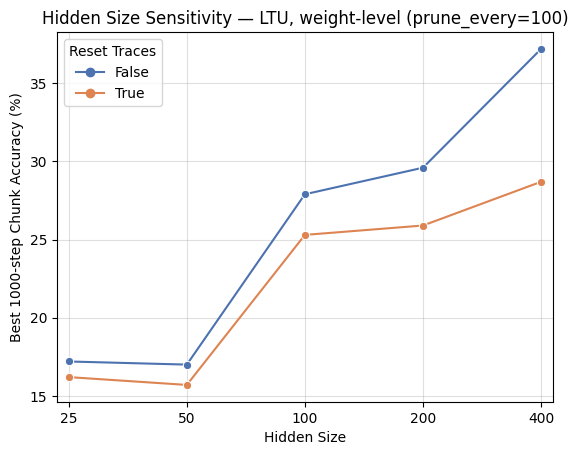

In [6]:
plot_param_sensitivity(
    run_df=run_df_1_ltu,
    config_df=config_df_1_ltu,
    x_col='hidden_size',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Hidden Size Sensitivity — LTU, weight-level (prune_every=100)',
    x_label='Hidden Size',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## Experiment 2: Prune Frequency Sensitivity (LTU)

How many steps should elapse between pruning a single weight? Hidden size is fixed at 1000 (so 10000 total W2 weights). Each point shows the best 1k-step chunk accuracy, with separate lines for reset vs. no-reset of utility traces after pruning.

In [ ]:
prune_every_values = [25, 50, 100, 200, 400] # [25, 50, 100, 200, 400, 800]

configs_exp2_ltu = [
    {'hidden_size': 100, 'prune_every': p, 'reset_traces_on_prune': r, 'activation': 'ltu'}
    for p, r in product(prune_every_values, reset_values)
]

run_df_2_ltu, config_df_2_ltu = run_sweep(configs_exp2_ltu)

In [ ]:
plot_param_sensitivity(
    run_df=run_df_2_ltu,
    config_df=config_df_2_ltu,
    x_col='prune_every',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Prune Frequency Sensitivity — LTU, weight-level (hidden_size=1000)',
    x_label='Prune Every (steps)',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## All Utility Functions — Both Sweeps

Run both sensitivity sweeps (hidden size, prune frequency) for every utility function defined above. Plots are rendered inline as soon as each individual sweep finishes, so the notebook isn't silent for the full duration. Results are stored in `all_results` for later inspection.

⚠️ Total runtime is roughly `9 utility functions × (exp1 + exp2)`. Drop the largest `hidden_size` / `prune_every` values in the config blocks above if needed.


=== Utility: v0 (baseline raw) ===


Sweep: 100%|██████████| 155000/155000 [00:24<00:00, 6335.28step/s, act=ltu, h=800, k=10, p=100, reset=1]


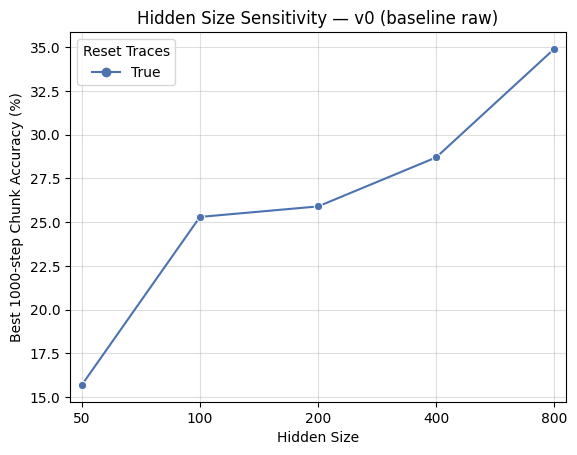

Sweep: 100%|██████████| 77500/77500 [00:08<00:00, 9411.51step/s, act=ltu, h=100, k=10, p=400, reset=1] 


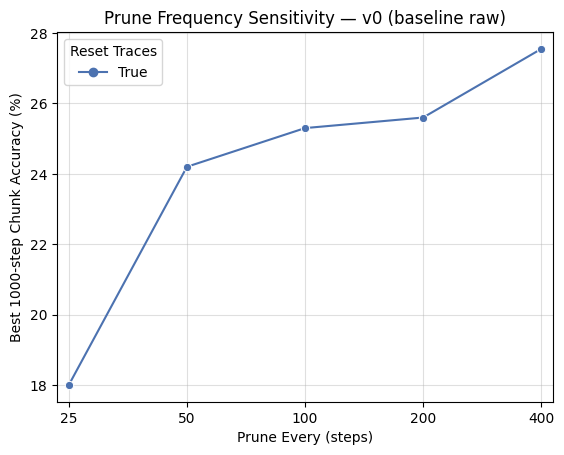


=== Utility: v0.5 (scale by raw sum) ===


Sweep: 100%|██████████| 155000/155000 [00:21<00:00, 7372.39step/s, act=ltu, h=800, k=10, p=100, reset=1] 


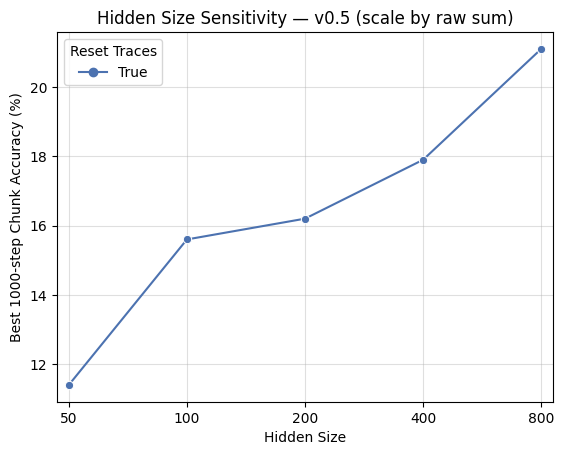

Sweep: 100%|██████████| 77500/77500 [00:09<00:00, 7898.57step/s, act=ltu, h=100, k=10, p=400, reset=1] 


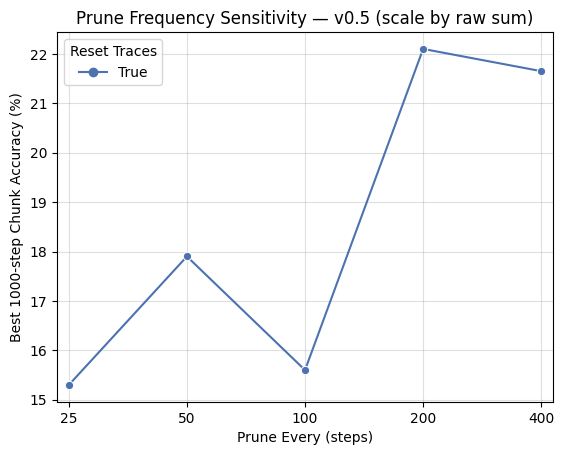


=== Utility: v1 (shift by min) ===


Sweep: 100%|██████████| 155000/155000 [00:22<00:00, 6990.98step/s, act=ltu, h=800, k=10, p=100, reset=1] 


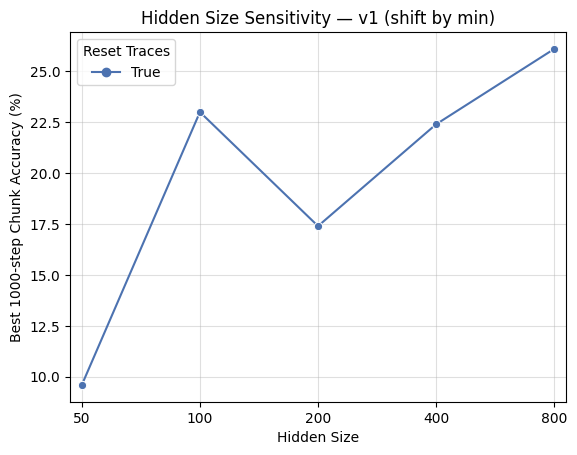

Sweep: 100%|██████████| 77500/77500 [00:09<00:00, 8014.32step/s, act=ltu, h=100, k=10, p=400, reset=1] 


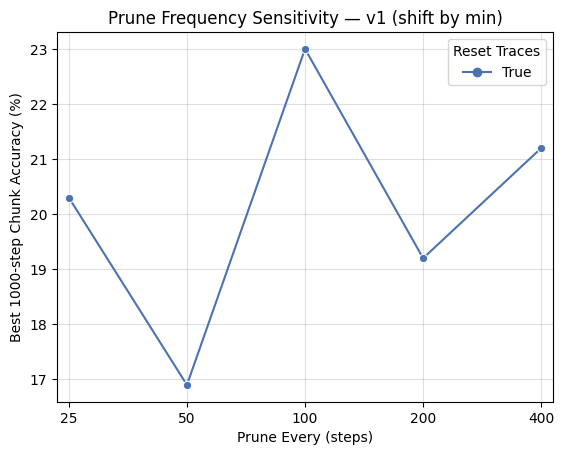


=== Utility: v2 (shift + scale) ===


Sweep: 100%|██████████| 155000/155000 [00:23<00:00, 6495.37step/s, act=ltu, h=800, k=10, p=100, reset=1]


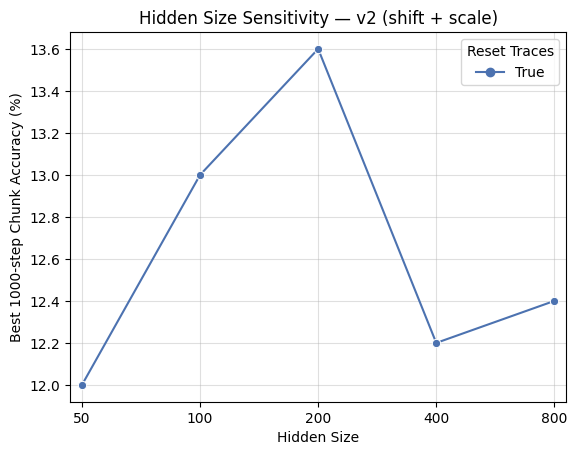

Sweep: 100%|██████████| 77500/77500 [00:10<00:00, 7120.72step/s, act=ltu, h=100, k=10, p=400, reset=1] 


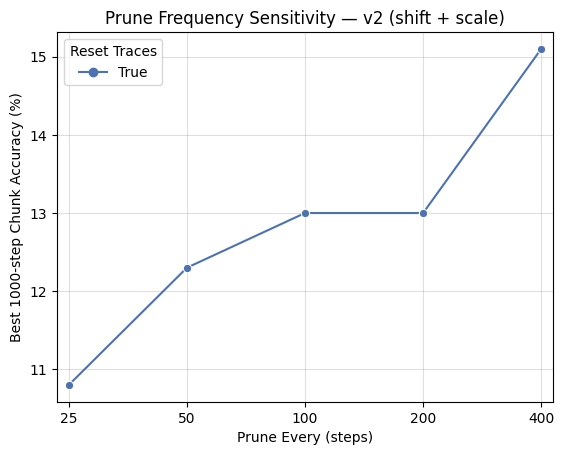


=== Utility: v3 (clamp neg) ===


Sweep: 100%|██████████| 155000/155000 [00:18<00:00, 8303.61step/s, act=ltu, h=800, k=10, p=100, reset=1] 


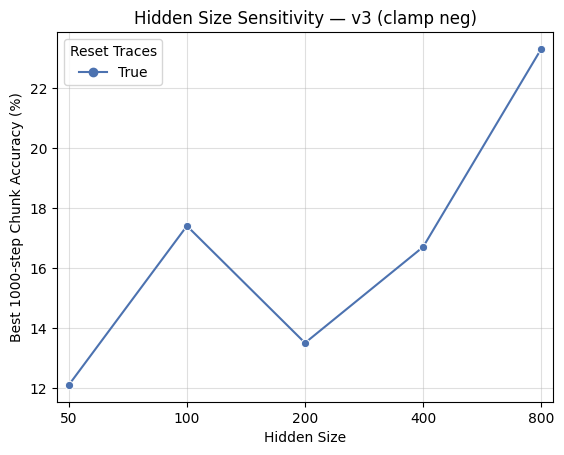

Sweep: 100%|██████████| 77500/77500 [00:08<00:00, 9403.48step/s, act=ltu, h=100, k=10, p=400, reset=1] 


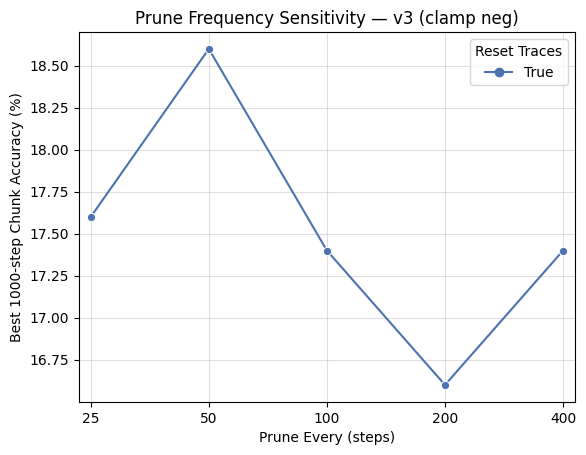


=== Utility: v4 (clamp + scale) ===


Sweep: 100%|██████████| 155000/155000 [00:22<00:00, 6932.72step/s, act=ltu, h=800, k=10, p=100, reset=1] 


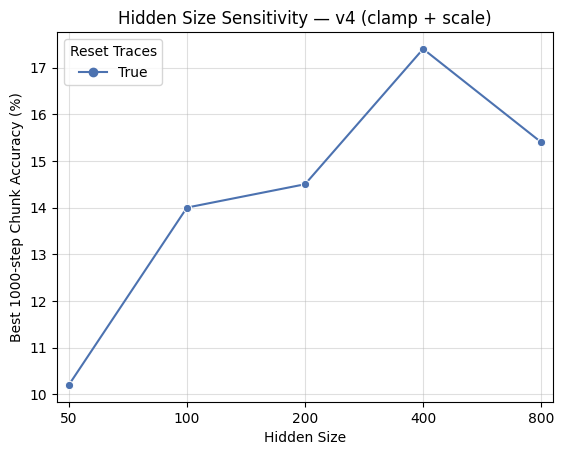

Sweep: 100%|██████████| 77500/77500 [00:09<00:00, 7879.47step/s, act=ltu, h=100, k=10, p=400, reset=1] 


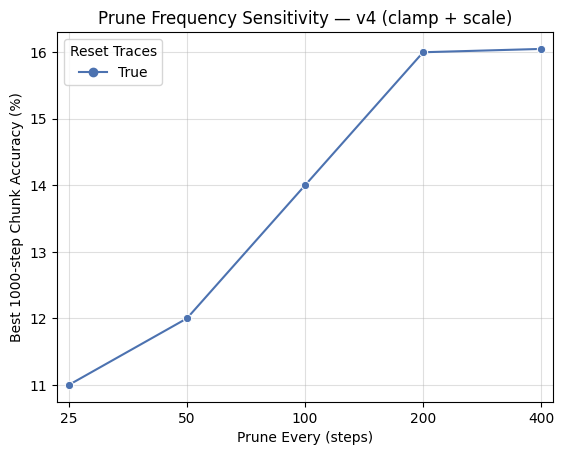


=== Utility: v5 (scale by abs sum) ===


Sweep: 100%|██████████| 155000/155000 [00:21<00:00, 7298.85step/s, act=ltu, h=800, k=10, p=100, reset=1] 


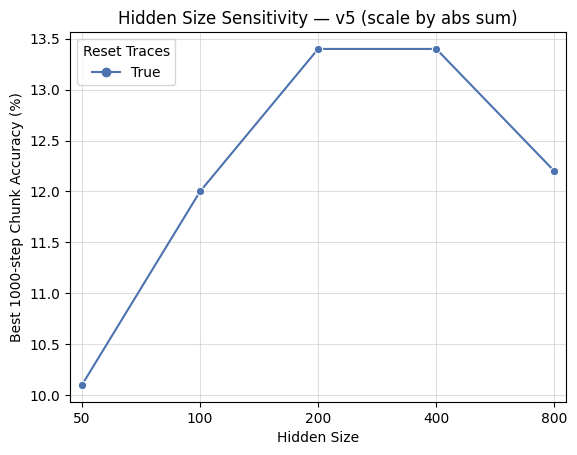

Sweep: 100%|██████████| 77500/77500 [00:10<00:00, 7720.35step/s, act=ltu, h=100, k=10, p=400, reset=1] 


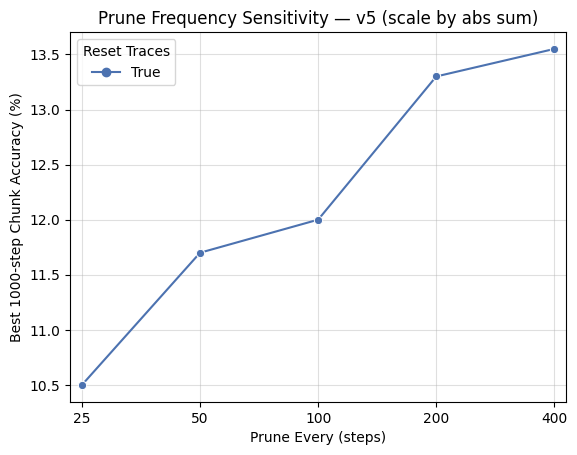


=== Utility: v6 (scale by pos sum) ===


Sweep: 100%|██████████| 155000/155000 [00:21<00:00, 7136.08step/s, act=ltu, h=800, k=10, p=100, reset=1] 


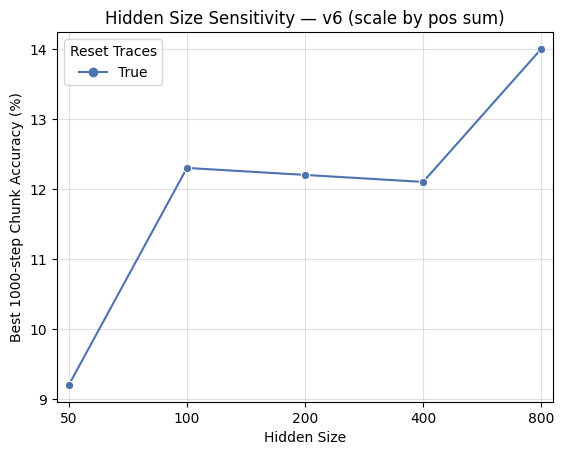

Sweep: 100%|██████████| 77500/77500 [00:09<00:00, 7933.83step/s, act=ltu, h=100, k=10, p=400, reset=1] 


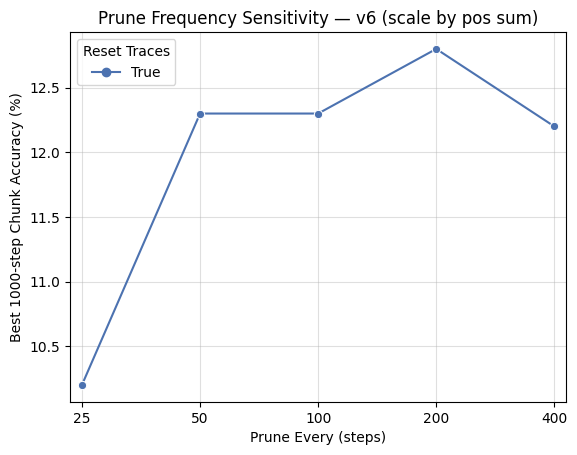


=== Utility: v7 (global scale) ===


Sweep: 100%|██████████| 155000/155000 [00:22<00:00, 6766.53step/s, act=ltu, h=800, k=10, p=100, reset=1] 


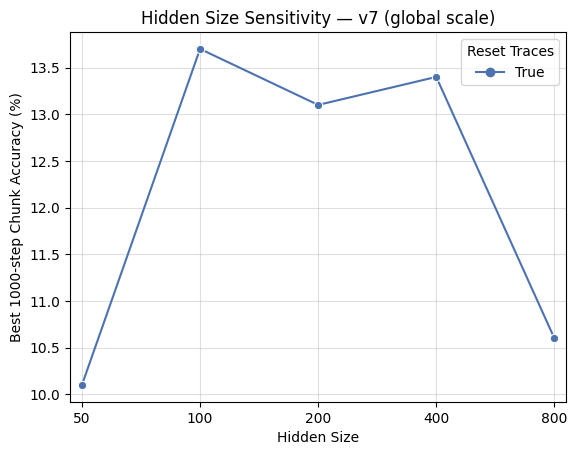

Sweep: 100%|██████████| 77500/77500 [00:10<00:00, 7342.01step/s, act=ltu, h=100, k=10, p=400, reset=1] 


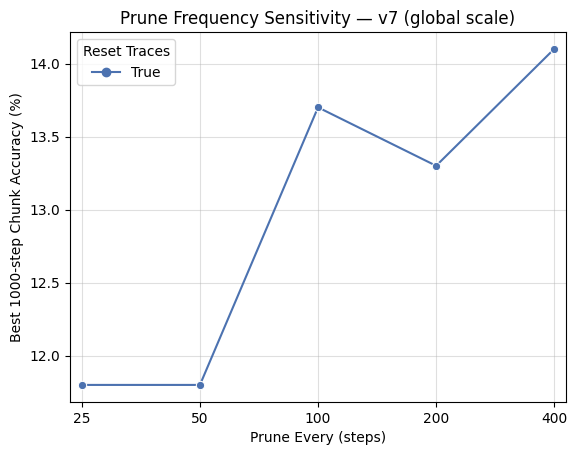


=== Utility: softmax-CE LOO ===


Sweep: 100%|██████████| 155000/155000 [01:43<00:00, 1498.58step/s, act=ltu, h=800, k=10, p=100, reset=1] 


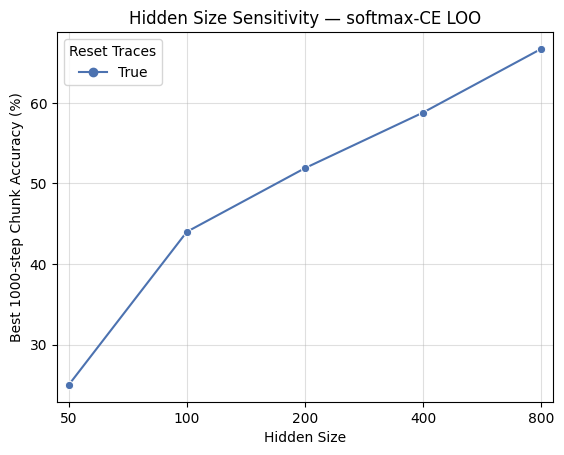

Sweep: 100%|██████████| 77500/77500 [01:37<00:00, 790.89step/s, act=ltu, h=100, k=10, p=400, reset=1]  


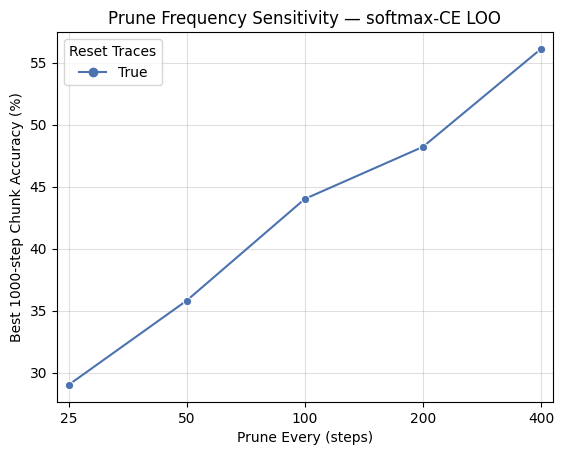

In [5]:
# === ALL UTILITY FUNCTIONS SWEEP ===
import matplotlib.pyplot as plt

UTIL_FNS = {
    'v0 (baseline raw)':       compute_weight_utility,
    'v0.5 (scale by raw sum)': compute_scaled_weight_utility,
    'v1 (shift by min)':       compute_weight_utility_v1,
    'v2 (shift + scale)':      compute_weight_utility_v2,
    'v3 (clamp neg)':          compute_weight_utility_v3,
    'v4 (clamp + scale)':      compute_weight_utility_v4,
    'v5 (scale by abs sum)':   compute_weight_utility_v5,
    'v6 (scale by pos sum)':   compute_weight_utility_v6,
    'v7 (global scale)':       compute_weight_utility_v7,
    'softmax-CE LOO':          compute_weight_utility_softmax_ce,
}

hidden_sizes = [50, 100, 200, 400, 800]
prune_every_values = [25, 50, 100, 200, 400]
reset_values = [True]

configs_exp1_ltu = [
    {'hidden_size': h, 'prune_every': 100, 'reset_traces_on_prune': r, 'activation': 'ltu'}
    for h, r in product(hidden_sizes, reset_values)
]

configs_exp2_ltu = [
    {'hidden_size': 100, 'prune_every': p, 'reset_traces_on_prune': r, 'activation': 'ltu'}
    for p, r in product(prune_every_values, reset_values)
]

all_results = {}

for util_name, util_fn in UTIL_FNS.items():
    print(f"\n=== Utility: {util_name} ===")
    # Updating the module-level UTIL_FN and clearing the JIT cache so the next
    # _get_scan_fn call re-traces with the new utility function.
    UTIL_FN = util_fn
    _scan_cache.clear()

    # --- Experiment 1: hidden size sweep ---
    run_df_1, config_df_1 = run_sweep(configs_exp1_ltu)
    plt.figure()
    plot_param_sensitivity(
        run_df=run_df_1,
        config_df=config_df_1,
        x_col='hidden_size',
        hue_col='reset_traces_on_prune',
        metric_col='best_chunk_accuracy',
        metric_type='last',
        title=f'Hidden Size Sensitivity — {util_name}',
        x_label='Hidden Size',
        y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
        legend_title='Reset Traces',
    )
    plt.show()

    # --- Experiment 2: prune-frequency sweep ---
    run_df_2, config_df_2 = run_sweep(configs_exp2_ltu)
    plt.figure()
    plot_param_sensitivity(
        run_df=run_df_2,
        config_df=config_df_2,
        x_col='prune_every',
        hue_col='reset_traces_on_prune',
        metric_col='best_chunk_accuracy',
        metric_type='last',
        title=f'Prune Frequency Sensitivity — {util_name}',
        x_label='Prune Every (steps)',
        y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
        legend_title='Reset Traces',
    )
    plt.show()

    all_results[util_name] = {
        'exp1': (run_df_1, config_df_1),
        'exp2': (run_df_2, config_df_2),
    }

# Restore baseline utility for any subsequent re-runs of the per-experiment cells above.
UTIL_FN = compute_weight_utility
_scan_cache.clear()